
# Results 5.1 — classifier figures

Seven figures for Chapter 5.1 (tutor-move classification).

Two parts.

**Part 1 — collect the data.** Opens the 18 classifier notebooks in
`0__final_classification/`, pulls the numbers out of their saved cell outputs, writes CSV.
No training, no re-prediction. Run once.

**Part 2 — draw the figures.** Reads those CSVs, nothing else. Re-run this part alone
whenever a figure needs changing.

Folders created:

| folder | contents |
|---|---|
| `result_5_1_data/` | CSVs from Part 1 |
| `result_5_1_figures/` | figures from Part 2 (PDF + PNG) |

For the thesis: copy the PDFs into `__Thesis_writing/TUM_Template/figures/`.

## 0. Setup

In [179]:
import json
from io import StringIO
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Repo root — this notebook sits next to 0__final_classification/.
ROOT = Path.cwd()
CLASSIFIER_DIR = ROOT / "0__final_classification"

# Output folders, created if missing.
DATA_DIR = ROOT / "result_5_1_data"
FIGURE_DIR = ROOT / "result_5_1_figures"
DATA_DIR.mkdir(exist_ok=True)
FIGURE_DIR.mkdir(exist_ok=True)

# Move order, fixed once, reused everywhere.
MOVES = ["focus", "generic", "probing", "telling"]

print("repository root :", ROOT)
print("classifier dir  :", CLASSIFIER_DIR.is_dir())

repository root : /Users/jay/Desktop/___TUM_Thesis /____Final_Thesis_Repository
classifier dir  : True



---

# Part 1 — collect the data

Results are already sitting in the 18 classifier notebooks as plain printed text:

```
[test classification report]
              precision    recall  f1-score   support

       focus       0.56      0.71      0.63       107
     generic       0.95      0.90      0.93       164
     ...

test_accuracy = 0.7355
test_macro_f1 = 0.6417
```

Part 1 reads that text back and turns it into tables. That's all.


## 1-1. Which notebook is which configuration

Could be parsed from the filenames. Written out instead — readable at a glance, no decoding.

Naming: `all_turns` in the filenames = **Preceding-2** in Chapter 4 (all three turns).

In [180]:
# filename -> (encoder, input representation, training objective)
NOTEBOOKS = {
    "Final_01_01__roBERTa__Weighted_CE__all_turns__refactored.ipynb":
        ("RoBERTa-base", "Preceding-2", "Weighted CE"),
    "Final_01_02__roBERTa__Weighted_CE__preceding_1__refactored.ipynb":
        ("RoBERTa-base", "Preceding-1", "Weighted CE"),
    "Final_01_03__roBERTa__Weighted_CE__tutor_turn_only__refactored.ipynb":
        ("RoBERTa-base", "Tutor-turn only", "Weighted CE"),

    "Final_02_01__roBERTa__DAM__all_turns__refactored.ipynb":
        ("RoBERTa-base", "Preceding-2", "AUC max."),
    "Final_02_02__roBERTa__DAM__preceding_1__refactored.ipynb":
        ("RoBERTa-base", "Preceding-1", "AUC max."),
    "Final_02_03__roBERTa__DAM__tutor_turn_only__refactored.ipynb":
        ("RoBERTa-base", "Tutor-turn only", "AUC max."),

    "Final_03_01__roBERTa__Focal__all_turns__refactored.ipynb":
        ("RoBERTa-base", "Preceding-2", "Focal loss"),
    "Final_03_02__roBERTa__Focal__preceding_1__refactored.ipynb":
        ("RoBERTa-base", "Preceding-1", "Focal loss"),
    "Final_03_03__roBERTa__Focal__tutor_turn_only__refactored.ipynb":
        ("RoBERTa-base", "Tutor-turn only", "Focal loss"),

    "Final_04_01__pretrained_roBERTa__Weighted_CE__all_turns__refactored.ipynb":
        ("DAPT", "Preceding-2", "Weighted CE"),
    "Final_04_02__pretrained_roBERTa__Weighted_CE__preceding_1__refactored.ipynb":
        ("DAPT", "Preceding-1", "Weighted CE"),
    "Final_04_03__pretrained_roBERTa__Weighted_CE__tutor_turn_only__refactored.ipynb":
        ("DAPT", "Tutor-turn only", "Weighted CE"),

    "Final_05_01__pretrained_roBERTa__DAM__all_turns__refactored.ipynb":
        ("DAPT", "Preceding-2", "AUC max."),
    "Final_05_02__pretrained_roBERTa__DAM__preceding_1__refactored.ipynb":
        ("DAPT", "Preceding-1", "AUC max."),
    "Final_05_03__pretrained_roBERTa__DAM__tutor_turn_only__refactored.ipynb":
        ("DAPT", "Tutor-turn only", "AUC max."),

    "Final_06_01__pretrained_roBERTa__Focal__all_turns__refactored.ipynb":
        ("DAPT", "Preceding-2", "Focal loss"),
    "Final_06_02__pretrained_roBERTa__Focal__preceding_1__refactored.ipynb":
        ("DAPT", "Preceding-1", "Focal loss"),
    "Final_06_03__pretrained_roBERTa__Focal__tutor_turn_only__refactored.ipynb":
        ("DAPT", "Tutor-turn only", "Focal loss"),
}

print("configurations:", len(NOTEBOOKS))

configurations: 18



## 1-2. Pulling the numbers out

Five short functions.

In [181]:
def get_printed_text(notebook):
    """Every print output in the notebook, glued into one string."""
    pieces = []
    for cell in notebook["cells"]:
        for output in cell.get("outputs", []):
            if output.get("output_type") == "stream":
                pieces.append("".join(output["text"]))
    return "\n".join(pieces)


def find_number_after(text, label):
    """Number after the '=' on a line like 'test_accuracy = 0.7355'."""
    for line in text.split("\n"):
        if line.startswith(label):
            return float(line.split("=")[1].strip())
    return None


def find_number_below(text, label):
    """Number on the line below its heading. MCC is printed that way."""
    lines = text.split("\n")
    for i, line in enumerate(lines):
        if label in line:
            return float(lines[i + 1].strip())
    return None

In [182]:
def read_classification_report(text):
    """Per-class precision / recall / support from the classification report.

    Target lines look like
        '       focus       0.56      0.71      0.63       107'
    Five whitespace-separated pieces, move name first. That check is enough.
    """
    rows = []
    for line in text.split("\n"):
        words = line.split()
        if len(words) == 5 and words[0] in MOVES:
            rows.append({
                "move": words[0],
                "precision": float(words[1]),
                "recall": float(words[2]),
                "support": int(words[4]),   # words[3] is F1 — recomputed below instead
            })
    return rows


def read_per_class_auc(text):
    """Per-class ROC-AUC from lines like 'focus = 0.7779'."""
    scores = {}
    for line in text.split("\n"):
        words = line.split()
        if len(words) == 3 and words[0] in MOVES and words[1] == "=":
            scores[words[0]] = float(words[2])
    return scores


def read_epoch_table(notebook):
    """The HTML table trainer.train() left behind, straight into pandas.

    The 'Epoch / Training Loss / Validation Loss / ...' table from training time.
    """
    for cell in notebook["cells"]:
        if "trainer.train()" not in "".join(cell["source"]):
            continue
        for output in cell.get("outputs", []):
            html = "".join(output.get("data", {}).get("text/html", ""))
            if "Epoch" in html:
                return pd.read_html(StringIO(html))[0]
    return None


## 1-3. Read all 18

One notebook at a time, three tables stacked.

In [183]:
summary_rows = []    # one row per classifier
per_class_rows = []  # one row per classifier x move -> four each
epoch_rows = []      # one row per classifier x epoch -> ten each

for filename, (encoder, representation, objective) in NOTEBOOKS.items():
    path = CLASSIFIER_DIR / filename
    notebook = json.loads(path.read_text())
    text = get_printed_text(notebook)

    # (1) overall scores
    summary_rows.append({
        "encoder": encoder,
        "representation": representation,
        "objective": objective,
        "accuracy": find_number_after(text, "test_accuracy"),
        "macro_f1": find_number_after(text, "test_macro_f1"),
        "macro_auc": find_number_after(text, "test_auc_macro_ovr"),
        "mcc": find_number_below(text, "[test matthews_corrcoef]"),
        "source_file": filename,
    })

    # (2) per-class scores
    auc_by_move = read_per_class_auc(text)
    for row in read_classification_report(text):
        row["encoder"] = encoder
        row["representation"] = representation
        row["objective"] = objective
        row["auc"] = auc_by_move.get(row["move"])
        per_class_rows.append(row)

    # (3) validation scores per epoch
    table = read_epoch_table(notebook)
    for _, row in table.iterrows():
        epoch_rows.append({
            "encoder": encoder,
            "representation": representation,
            "objective": objective,
            "epoch": int(row["Epoch"]),
            "val_macro_f1": float(row["F1 Macro"]),
            "val_loss": float(row["Validation Loss"]),
        })

summary = pd.DataFrame(summary_rows)
per_class = pd.DataFrame(per_class_rows)
epochs = pd.DataFrame(epoch_rows)

print("summary  :", summary.shape, "(18 configurations)")
print("per_class:", per_class.shape, "(18 x 4 = 72 rows)")
print("epochs   :", epochs.shape, "(18 x 10 = 180 rows)")
summary.head()

summary  : (18, 8) (18 configurations)
per_class: (72, 8) (18 x 4 = 72 rows)
epochs   : (180, 6) (18 x 10 = 180 rows)


,encoder,representation,objective,accuracy,macro_f1,macro_auc,mcc,source_file
0,RoBERTa-base,Preceding-2,Weighted CE,0.5377,0.3423,0.7607,0.218798,Final_01_01__roBERTa__Weighted_CE__all_turns__...
1,RoBERTa-base,Preceding-1,Weighted CE,0.5678,0.4476,0.7513,0.276275,Final_01_02__roBERTa__Weighted_CE__preceding_1...
2,RoBERTa-base,Tutor-turn only,Weighted CE,0.7154,0.6121,0.8340,0.579583,Final_01_03__roBERTa__Weighted_CE__tutor_turn_...
3,RoBERTa-base,Preceding-2,AUC max.,0.6030,0.3957,0.7468,0.323507,Final_02_01__roBERTa__DAM__all_turns__refactor...
4,RoBERTa-base,Preceding-1,AUC max.,0.6080,0.4788,0.7555,0.339980,Final_02_02__roBERTa__DAM__preceding_1__refact...



## 1-4. Exact per-class F1

The classification report prints F1 to two decimals only — too coarse for a figure.

recall and support give the underlying counts back:

```
correct   = recall x support
predicted = correct / precision
F1        = 2 x correct / (support + predicted)
```

Counts are integers, so rounding lands back on the originals. Check below: the mean of
these should equal the `test_macro_f1` each notebook printed.

In [184]:
# Correct predictions, recovered as an integer.
per_class["correct"] = (per_class["recall"] * per_class["support"]).round().astype(int)

# Predictions made for that class.
# precision is 0.00 wherever a class was never predicted — nothing to divide by.
# Those rows get 0, which makes F1 below come out 0 as well.
per_class["predicted"] = 0
can_divide = per_class["precision"] > 0
per_class.loc[can_divide, "predicted"] = (
    per_class.loc[can_divide, "correct"] / per_class.loc[can_divide, "precision"]
).round().astype(int)

# F1 again, from the recovered counts.
per_class["f1"] = 2 * per_class["correct"] / (per_class["support"] + per_class["predicted"])

# --- check: mean of the per-class F1 values == macro F1 ---------------------
check = per_class.groupby(["encoder", "representation", "objective"])["f1"].mean()
check = check.rename("macro_f1_recomputed").reset_index()
check = check.merge(summary, on=["encoder", "representation", "objective"])
largest_gap = (check["macro_f1_recomputed"] - check["macro_f1"]).abs().max()

print(f"largest gap between recovered and reported macro F1: {largest_gap:.4f}")
assert largest_gap < 0.002, "gap too large — parsing is off somewhere"
print("check passed")

largest gap between recovered and reported macro F1: 0.0016
check passed



### Macro F1 without Generic

`Generic` is a very different size per representation — 820 of 1,982 examples under
tutor-turn only, 72 of 991 under Preceding-1/-2. So both primary metrics recomputed over
the other three moves, to see whether the ordering of the representations survives without
it. Figure 5.3.

In [185]:
three_moves = per_class[per_class["move"] != "generic"]
keys = ["encoder", "representation", "objective"]

for column, new_name in [("f1", "macro_f1_no_generic"), ("auc", "macro_auc_no_generic")]:
    without_generic = three_moves.groupby(keys)[column].mean().rename(new_name).reset_index()
    summary = summary.merge(without_generic, on=keys)

summary[keys + ["macro_f1", "macro_f1_no_generic",
                "macro_auc", "macro_auc_no_generic"]].head()

,encoder,representation,objective,macro_f1,macro_f1_no_generic,macro_auc,macro_auc_no_generic
0,RoBERTa-base,Preceding-2,Weighted CE,0.3423,0.387469,0.7607,0.743200
1,RoBERTa-base,Preceding-1,Weighted CE,0.4476,0.474531,0.7513,0.719167
2,RoBERTa-base,Tutor-turn only,Weighted CE,0.6121,0.510870,0.8340,0.798067
3,RoBERTa-base,Preceding-2,AUC max.,0.3957,0.428838,0.7468,0.768800
4,RoBERTa-base,Preceding-1,AUC max.,0.4788,0.528414,0.7555,0.761700



## 1-5. Confusion matrix, selected classifier

Different from the rest. The classifier notebooks saved this one as an *image*, so there is
no text to read back — numbers typed in from the figure.

Two checks against the counts recovered above: row sums = support, diagonal = correct.

In [186]:
# Selected classifier: RoBERTa-base + Tutor-turn only + AUC max.
# Rows = true label, columns = prediction, order focus / generic / probing / telling.
confusion = pd.DataFrame(
    [[76,   7,  19,  5],
     [ 8, 148,   6,  2],
     [46,   1,  62,  4],
     [ 5,   0,   2,  6]],
    index=MOVES, columns=MOVES,
)

# --- check 1: row sums == support ------------------------------------------
selected = per_class[(per_class["encoder"] == "RoBERTa-base")
                     & (per_class["representation"] == "Tutor-turn only")
                     & (per_class["objective"] == "AUC max.")]
selected = selected.set_index("move").loc[MOVES]

assert list(confusion.sum(axis=1)) == list(selected["support"])
print("check 1 passed, row sums:", list(confusion.sum(axis=1)))

# --- check 2: diagonal == recovered 'correct' counts -----------------------
assert np.diag(confusion).tolist() == list(selected["correct"])
print("check 2 passed, diagonal:", np.diag(confusion).tolist())

confusion

check 1 passed, row sums: [107, 164, 113, 13]
check 2 passed, diagonal: [76, 148, 62, 6]


,focus,generic,probing,telling
focus,76,7,19,5
generic,8,148,6,2
probing,46,1,62,4
telling,5,0,2,6


## 1-6. Save to CSV

In [187]:
# One aggregated table too — figure 5.2 wants mean / min / max across the three
# objectives within each encoder x representation, for both metrics.
per_class_avg = per_class.groupby(["encoder", "representation", "move"]).agg(
    f1_mean=("f1", "mean"),
    f1_min=("f1", "min"),
    f1_max=("f1", "max"),
    auc_mean=("auc", "mean"),
    auc_min=("auc", "min"),
    auc_max=("auc", "max"),
    support=("support", "first"),
).reset_index()

summary.to_csv(DATA_DIR / "summary.csv", index=False)
per_class.to_csv(DATA_DIR / "per_class.csv", index=False)
per_class_avg.to_csv(DATA_DIR / "per_class_avg.csv", index=False)
epochs.to_csv(DATA_DIR / "epochs.csv", index=False)
confusion.to_csv(DATA_DIR / "confusion_selected.csv")

for file in sorted(DATA_DIR.glob("*.csv")):
    print(f"{file.name:26} {len(pd.read_csv(file)):4d} rows")

confusion_selected.csv        4 rows
epochs.csv                  180 rows
per_class.csv                72 rows
per_class_avg.csv            24 rows
summary.csv                  18 rows



---

# Part 2 — draw the figures

Only the CSVs from here on. Changing a figure: run `0. Setup`, then Part 2.
Part 1 stays put.

## 2-0. Load the CSVs and set up

In [188]:
summary = pd.read_csv(DATA_DIR / "summary.csv")
per_class = pd.read_csv(DATA_DIR / "per_class.csv")
per_class_avg = pd.read_csv(DATA_DIR / "per_class_avg.csv")
epochs = pd.read_csv(DATA_DIR / "epochs.csv")
confusion = pd.read_csv(DATA_DIR / "confusion_selected.csv", index_col=0)

MOVES = ["focus", "generic", "probing", "telling"]
MOVE_LABELS = {"focus": "Focus", "generic": "Generic",
               "probing": "Probing", "telling": "Telling"}

# Display order, everywhere.
REPRESENTATIONS = ["Preceding-2", "Preceding-1", "Tutor-turn only"]
OBJECTIVES = ["Weighted CE", "AUC max.", "Focal loss"]
ENCODERS = ["RoBERTa-base", "DAPT"]
ENCODER_TITLES = {"RoBERTa-base": "RoBERTa-base",
                  "DAPT": "Domain-adapted RoBERTa (DAPT)"}

print(len(summary), "configurations loaded")

18 configurations loaded


In [189]:
# --- colours and fonts ---------------------------------------------------
# Three colours that stay apart under colour vision deficiency: blue / orange / teal.
COLOR = {"Weighted CE": "#2a78d6", "AUC max.": "#eb6834", "Focal loss": "#1baf7a"}
COLOR_BY_REPRESENTATION = {"Preceding-2": "#2a78d6",
                           "Preceding-1": "#eb6834",
                           "Tutor-turn only": "#1baf7a"}
BLUE_SHADES = ["#cde2fb", "#9ec5f4", "#6da7ec", "#2a78d6"]

INK = "#0b0b0b"    # main text
GREY = "#52514e"   # secondary text
PALE = "#8a8a85"   # faint lines

plt.rcParams.update({
    "figure.dpi": 130,
    "savefig.dpi": 300,
    "font.family": "serif",
    "font.size": 9,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.edgecolor": PALE,
    "axes.linewidth": 0.7,
    "xtick.color": GREY, "ytick.color": GREY,
    "xtick.labelsize": 8, "ytick.labelsize": 8,
    "grid.color": "#dcdcd7", "grid.linewidth": 0.6,
    "legend.frameon": False, "legend.fontsize": 8,
})

In [190]:
# --- three helpers, used by every figure ---------------------------------

# Grey line at the top of each figure naming the models it covers.
# The LaTeX captions say it too, so False turns it off.
SHOW_MODEL_NOTE = True

ALL_18 = ("18 classifiers  =  {RoBERTa-base, domain-adapted RoBERTa}  $\\times$  "
          "{Preceding-2, Preceding-1, Tutor-turn only}  $\\times$  "
          "{weighted CE, AUC maximization, focal loss}")
SELECTED_ONLY = ("selected classifier  =  RoBERTa-base  $\\cdot$  Tutor-turn only  "
                 "$\\cdot$  AUC maximization   (397 test examples)")


def add_model_note(fig, note, y=1.04):
    if SHOW_MODEL_NOTE:
        fig.text(0.5, y, note, ha="center", va="bottom",
                 fontsize=6.8, color=PALE, style="italic")


def save(fig, name):
    fig.savefig(FIGURE_DIR / f"{name}.pdf", bbox_inches="tight")
    fig.savefig(FIGURE_DIR / f"{name}.png", bbox_inches="tight")
    print("saved", name)


def pick(table, **conditions):
    """Rows matching every condition. pick(summary, encoder='DAPT')."""
    for column, value in conditions.items():
        table = table[table[column] == value]
    return table


## 2-1. Figure 5.1 — both primary metrics, all 18

Top row macro F1, bottom row macro one-vs-rest ROC-AUC.
Panels = input representation, rows within a panel = training objective.
Two markers per row joined by a line: small filled dot = RoBERTa-base, wider ring = DAPT.
The line shows which way DAPT moved it.

Some pairs differ by less than the marker width (Preceding-2 / focal by 0.004 on F1), so
the dot sits inside the ring there rather than beside it. All 18 are on the figure.

The two rows carry different scales — F1 spans 0.20--0.72, ROC-AUC 0.66--0.90.

saved fig_5_1_overview


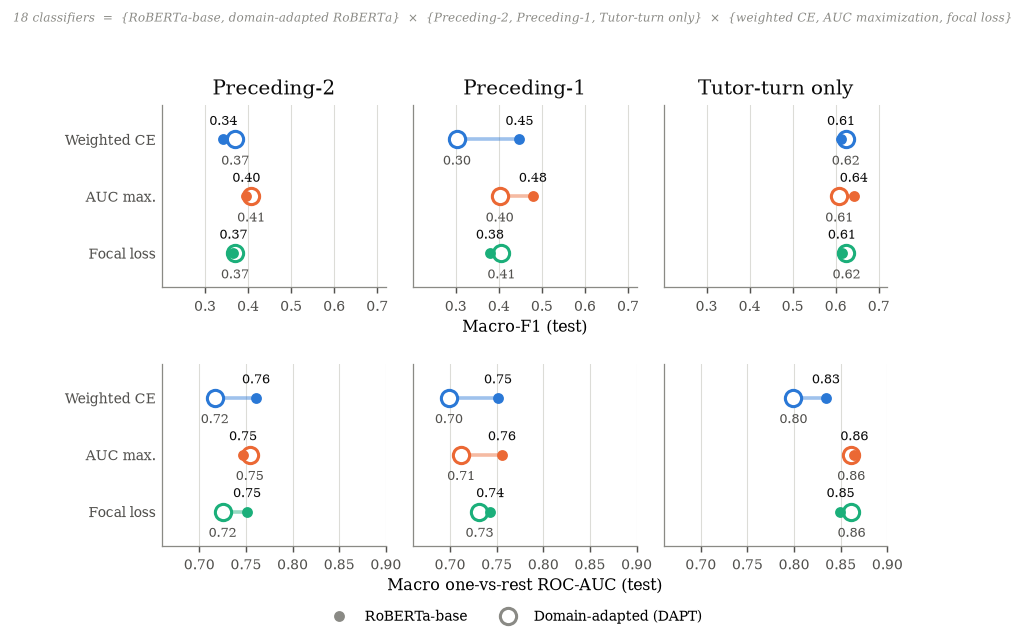

In [191]:
# Row 1 = macro F1, row 2 = macro ROC-AUC. Each row has its own x range.
rows_to_draw = [
    ("macro_f1",  "Macro-F1 (test)",                  (0.20, 0.72), [0.3, 0.4, 0.5, 0.6, 0.7]),
    ("macro_auc", "Macro one-vs-rest ROC-AUC (test)", (0.66, 0.90), [0.70, 0.75, 0.80, 0.85, 0.90]),
]

fig, axes = plt.subplots(2, 3, figsize=(7.2, 4.4), sharey=True)

for row_index, (column, xlabel, xlim, xticks) in enumerate(rows_to_draw):
    for column_index, representation in enumerate(REPRESENTATIONS):
        panel = axes[row_index, column_index]

        for i, objective in enumerate(OBJECTIVES):
            # Top to bottom: Weighted CE, AUC max., Focal loss.
            y = len(OBJECTIVES) - 1 - i
            color = COLOR[objective]

            base = pick(summary, encoder="RoBERTa-base",
                        representation=representation, objective=objective)[column].item()
            dapt = pick(summary, encoder="DAPT",
                        representation=representation, objective=objective)[column].item()

            # DAPT ring first and wider, base dot on top and smaller. Same size and the ring
            # hides the dot wherever the two nearly coincide.
            panel.plot([base, dapt], [y, y], color=color, linewidth=2, alpha=0.45)
            panel.plot(dapt, y, "o", markersize=9.0, markerfacecolor="white",
                       markeredgecolor=color, markeredgewidth=1.7)
            panel.plot(base, y, "o", markersize=5.0, color=color)

            panel.annotate(f"{base:.2f}", (base, y), xytext=(0, 8),
                           textcoords="offset points", ha="center", fontsize=7.0, color=INK)
            panel.annotate(f"{dapt:.2f}", (dapt, y), xytext=(0, -14),
                           textcoords="offset points", ha="center", fontsize=7.0, color=GREY)

        panel.set_xlim(*xlim)
        panel.set_xticks(xticks)
        panel.set_ylim(-0.6, len(OBJECTIVES) - 0.4)
        panel.xaxis.grid(True)
        panel.set_axisbelow(True)
        panel.tick_params(axis="y", length=0)
        if row_index == 0:
            panel.set_title(representation, color=INK, pad=6)

    # x label under the middle panel of each row
    axes[row_index, 1].set_xlabel(xlabel, fontsize=8.6, labelpad=3)
    axes[row_index, 0].set_yticks([2, 1, 0])
    axes[row_index, 0].set_yticklabels(OBJECTIVES)

# Legend under the whole figure, once.
legend_items = [
    plt.Line2D([], [], marker="o", linestyle="", markersize=5.0,
               markerfacecolor=PALE, markeredgecolor=PALE, label="RoBERTa-base"),
    plt.Line2D([], [], marker="o", linestyle="", markersize=9.0,
               markerfacecolor="white", markeredgecolor=PALE, markeredgewidth=1.7,
               label="Domain-adapted (DAPT)"),
]
fig.subplots_adjust(wspace=0.12, hspace=0.42)
fig.legend(handles=legend_items, loc="lower center", ncol=2,
           bbox_to_anchor=(0.5, -0.05), columnspacing=1.8)
add_model_note(fig, ALL_18, y=1.02)

save(fig, "fig_5_1_overview")
plt.show()


## 2-2. Figure 5.2 — per-class scores

Top row per-class F1, bottom row per-class ROC-AUC. Columns = encoder.
Bars = mean over the three objectives, whiskers = min and max of those three.
`per_class_avg.csv` already holds mean / min / max for both metrics.

Worth reading both rows together: `Focus` and `Probing` look flat on F1 but clearly rise
on ROC-AUC, and `Telling` does the opposite.

saved fig_5_2_perclass


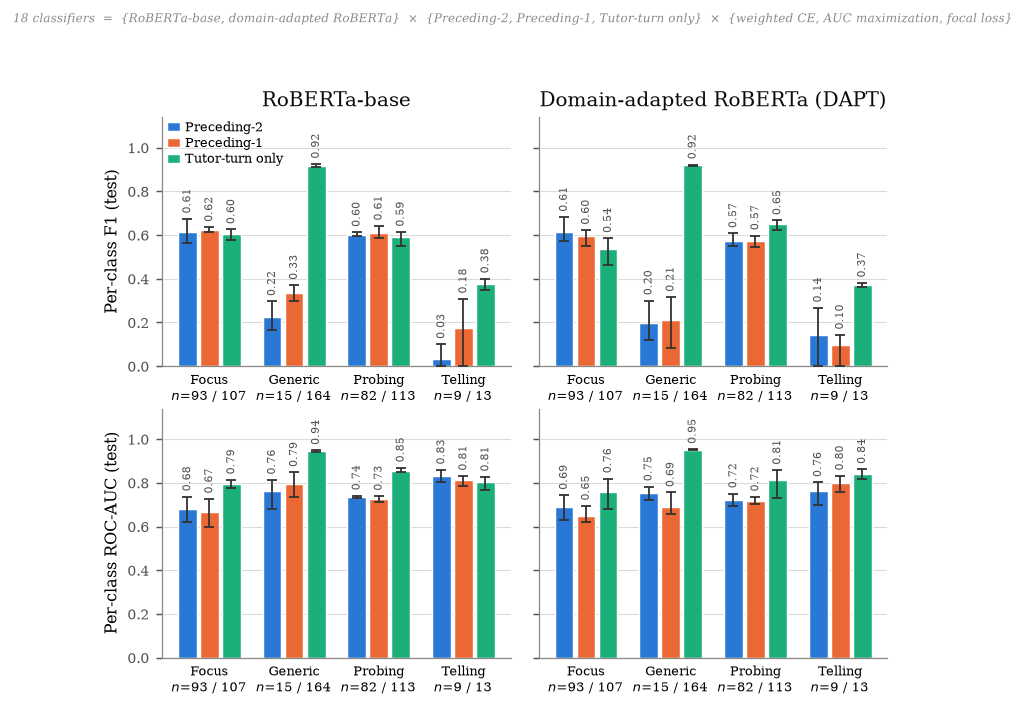

In [207]:
metrics_to_draw = [("f1", "Per-class F1 (test)"), ("auc", "Per-class ROC-AUC (test)")]

fig, axes = plt.subplots(2, 2, figsize=(7.2, 5.4), sharey=True)

bar_width = 0.26
x = np.arange(len(MOVES))

for row_index, (metric, ylabel) in enumerate(metrics_to_draw):
    for column_index, encoder in enumerate(ENCODERS):
        panel = axes[row_index, column_index]

        for i, representation in enumerate(REPRESENTATIONS):
            rows = pick(per_class_avg, encoder=encoder, representation=representation)
            rows = rows.set_index("move").loc[MOVES]

            position = x + (i - 1) * bar_width
            mean = rows[f"{metric}_mean"].values
            low = rows[f"{metric}_min"].values
            high = rows[f"{metric}_max"].values

            panel.bar(position, mean, bar_width * 0.86,
                      color=COLOR_BY_REPRESENTATION[representation],
                      label=representation, edgecolor="white", linewidth=0.8, zorder=2)
            # errorbar takes distances, not positions: down to the min, up to the max.
            panel.errorbar(position, mean, yerr=[mean - low, high - mean],
                           fmt="none", ecolor="#33322f", elinewidth=1.0, capsize=2.5,
                           zorder=4)
            # Numbers above the whisker, sideways so they fit.
            for xi, value, top in zip(position, mean, high):
                panel.annotate(f"{value:.2f}", (xi, top), xytext=(0, 3),
                               textcoords="offset points", ha="center", va="bottom",
                               rotation=90, fontsize=6.2, color=GREY)

        panel.set_ylim(0, 1.14)
        panel.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
        panel.yaxis.grid(True)
        panel.set_axisbelow(True)
        panel.tick_params(axis="x", length=0)
        panel.set_xticks(x)

        # Test counts in the x labels: Preceding-1/-2 count / Tutor-turn only count.
        # Shown under both rows, not just the bottom one.
        labels = []
        for move in MOVES:
            few = pick(per_class_avg, encoder=encoder,
                       representation="Preceding-1", move=move)["support"].item()
            many = pick(per_class_avg, encoder=encoder,
                        representation="Tutor-turn only", move=move)["support"].item()
            labels.append(f"{MOVE_LABELS[move]}\n$n$={few} / {many}")
        panel.set_xticklabels(labels, fontsize=7.4, color="black")

        if row_index == 0:
            panel.set_title(ENCODER_TITLES[encoder], color=INK, pad=6)

        if column_index == 0:
            panel.set_ylabel(ylabel, fontsize=8.6)

axes[0, 0].legend(loc="upper left", bbox_to_anchor=(-0.02, 1.03), fontsize=7.2,
                  labelspacing=0.2, handlelength=1.0, handletextpad=0.4)
# Extra vertical room so the top row's (two-line) x labels don't sit under the bottom row.
fig.subplots_adjust(wspace=0.08, hspace=0.17)
add_model_note(fig, ALL_18, y=1.01)

save(fig, "fig_5_2_perclass")
plt.show()


## 2-3. Figure 5.3 — ordering without Generic

Top row macro F1, bottom row macro ROC-AUC. Columns = encoder.
Dark bar = the metric over all four moves, light bar = the same with `Generic` dropped.
Dashed line through the light bars makes the ordering readable at a glance.

The two rows answer the same question differently: on F1 the gap shrinks a lot when
`Generic` goes, on ROC-AUC it barely moves.

saved fig_5_3_generic_effect


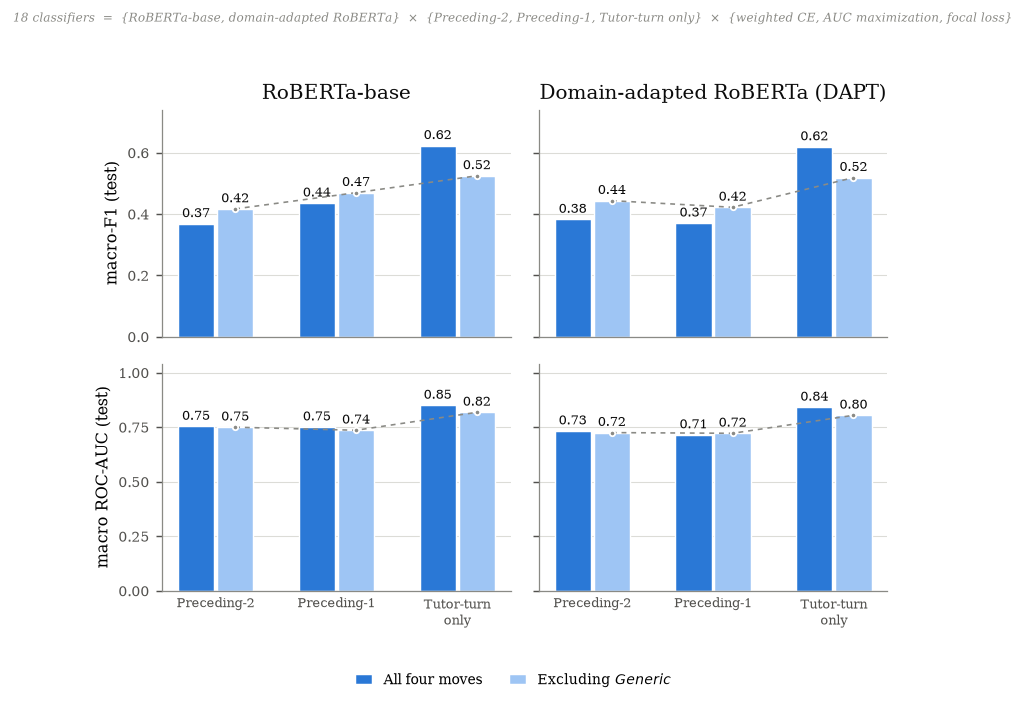

In [208]:
rows_to_draw = [("macro_f1",  "macro_f1_no_generic",  "macro-F1 (test)",
                 0.74, [0, 0.2, 0.4, 0.6]),
                ("macro_auc", "macro_auc_no_generic", "macro ROC-AUC (test)",
                 1.04, [0, 0.25, 0.5, 0.75, 1.0])]

fig, axes = plt.subplots(2, 2, figsize=(7.2, 5.0))

bar_width = 0.30
x = np.arange(len(REPRESENTATIONS))

for row_index, (column_all, column_no_generic, ylabel, ymax, yticks) in enumerate(rows_to_draw):
    for column_index, encoder in enumerate(ENCODERS):
        panel = axes[row_index, column_index]

        # Mean over the three objectives.
        rows = pick(summary, encoder=encoder)
        rows = rows.groupby("representation")[[column_all, column_no_generic]].mean()
        rows = rows.loc[REPRESENTATIONS]

        all_four = rows[column_all].values
        without_generic = rows[column_no_generic].values

        left = panel.bar(x - bar_width / 2 - 0.012, all_four, bar_width,
                         color="#2a78d6", edgecolor="white", linewidth=0.8,
                         label="All four moves", zorder=2)
        right = panel.bar(x + bar_width / 2 + 0.012, without_generic, bar_width,
                          color="#9ec5f4", edgecolor="white", linewidth=0.8,
                          label="Excluding $\\it{Generic}$", zorder=2)

        panel.bar_label(left, fmt="%.2f", padding=2, fontsize=7.0, color=INK)
        panel.bar_label(right, fmt="%.2f", padding=2, fontsize=7.0, color=INK)

        # Dashed line through the light bars.
        panel.plot(x + bar_width / 2 + 0.012, without_generic, color=PALE, linewidth=0.9,
                   linestyle=(0, (3, 3)), marker="o", markersize=3,
                   markerfacecolor=PALE, markeredgecolor="white", zorder=3)

        panel.set_ylim(0, ymax)
        panel.set_yticks(yticks)
        panel.yaxis.grid(True)
        panel.set_axisbelow(True)
        panel.tick_params(axis="x", length=0)
        panel.set_xticks(x)

        if row_index == 0:
            panel.set_title(ENCODER_TITLES[encoder], color=INK, pad=6)
            panel.set_xticklabels([])
        else:
            panel.set_xticklabels([n.replace(" only", "\nonly") for n in REPRESENTATIONS],
                                  fontsize=7.4)
        if column_index == 0:
            panel.set_ylabel(ylabel, fontsize=8.6)
        else:
            panel.set_yticklabels([])

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=2, bbox_to_anchor=(0.5, -0.03),
           fontsize=8, handlelength=1.2, columnspacing=1.8)
fig.subplots_adjust(wspace=0.08, hspace=0.12, bottom=0.14)
add_model_note(fig, ALL_18, y=1.01)

save(fig, "fig_5_3_generic_effect")
plt.show()


## 2-4. Figure 5.4 — validation macro F1 per epoch

Solid = RoBERTa-base, dashed = DAPT. The question: does Tutor-turn only sit on top the
whole way through, or only at the last checkpoint.

F1 only here. The per-epoch log carries macro ROC-AUC for the six AUC-maximization runs
alone, since those are the ones that monitor it for checkpoint selection, so there is no
comparable AUC curve for the other twelve.

saved fig_5_4_val_curves


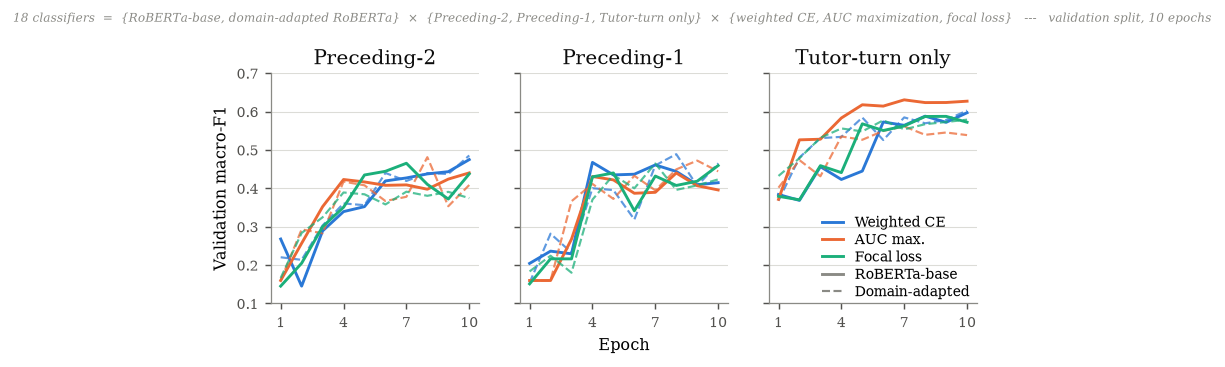

In [209]:
fig, axes = plt.subplots(1, 3, figsize=(7.0, 2.3), sharey=True)

for panel, representation in zip(axes, REPRESENTATIONS):
    for objective in OBJECTIVES:
        for encoder in ENCODERS:
            rows = pick(epochs, encoder=encoder,
                        representation=representation, objective=objective)
            rows = rows.sort_values("epoch")
            panel.plot(rows["epoch"], rows["val_macro_f1"],
                       color=COLOR[objective],
                       linestyle="-" if encoder == "RoBERTa-base" else "--",
                       linewidth=1.6 if encoder == "RoBERTa-base" else 1.2,
                       alpha=1.0 if encoder == "RoBERTa-base" else 0.75)

    panel.set_title(representation, color=INK, pad=5)
    panel.set_xticks([1, 4, 7, 10])
    panel.set_ylim(0.10, 0.70)
    panel.yaxis.grid(True)
    panel.set_axisbelow(True)

axes[0].set_ylabel("Validation macro-F1")
axes[1].set_xlabel("Epoch")

legend_items = [plt.Line2D([], [], color=COLOR[o], linewidth=1.6, label=o)
                for o in OBJECTIVES]
legend_items += [
    plt.Line2D([], [], color=PALE, linewidth=1.6, label="RoBERTa-base"),
    plt.Line2D([], [], color=PALE, linewidth=1.2, linestyle="--", label="Domain-adapted"),
]
axes[2].legend(handles=legend_items, loc="lower right", handlelength=1.5,
               labelspacing=0.2, bbox_to_anchor=(1.03, -0.04))
add_model_note(fig, ALL_18 + "   ---   validation split, 10 epochs")

save(fig, "fig_5_4_val_curves")
plt.show()


## 2-5. Figure 5.5 — macro F1 against macro AUC

18 points. Colour = objective, marker shape = input representation, hollow = DAPT.
Up and to the right is better.

saved fig_5_5_f1_vs_auc


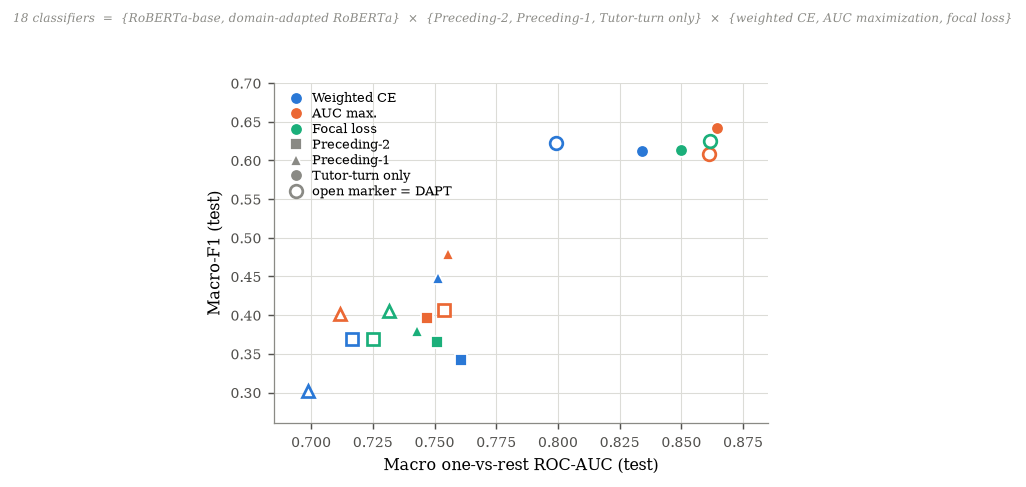

In [210]:
MARKER = {"Preceding-2": "s", "Preceding-1": "^", "Tutor-turn only": "o"}

fig, ax = plt.subplots(figsize=(4.9, 3.4))

# One point per row of the table.
for _, row in summary.iterrows():
    is_base = row["encoder"] == "RoBERTa-base"
    color = COLOR[row["objective"]]
    ax.plot(row["macro_auc"], row["macro_f1"],
            marker=MARKER[row["representation"]], markersize=7,
            markerfacecolor=color if is_base else "white",
            markeredgecolor="white" if is_base else color,
            markeredgewidth=1.0 if is_base else 1.5)

ax.set_xlim(0.685, 0.885)
ax.set_ylim(0.26, 0.70)
ax.set_xlabel("Macro one-vs-rest ROC-AUC (test)")
ax.set_ylabel("Macro-F1 (test)")
ax.grid(True)
ax.set_axisbelow(True)

legend_items = [plt.Line2D([], [], marker="o", linestyle="", markersize=7,
                           markerfacecolor=COLOR[o], markeredgecolor="white", label=o)
                for o in OBJECTIVES]
legend_items += [plt.Line2D([], [], marker=MARKER[r], linestyle="", markersize=7,
                            markerfacecolor=PALE, markeredgecolor="white", label=r)
                 for r in REPRESENTATIONS]
legend_items += [plt.Line2D([], [], marker="o", linestyle="", markersize=7,
                            markerfacecolor="white", markeredgecolor=PALE,
                            markeredgewidth=1.5, label="open marker = DAPT")]
ax.legend(handles=legend_items, loc="upper left", labelspacing=0.2,
          handletextpad=0.3, fontsize=7.0, borderpad=0.2)
add_model_note(fig, ALL_18, y=1.01)

save(fig, "fig_5_5_f1_vs_auc")
plt.show()


## 2-6. Figure 5.6 — selected classifier, close up

Left: per-class precision / recall / F1 / ROC-AUC. Right: confusion matrix — seaborn's
`heatmap` does it in one line.

Red box on the right: `Probing` read as `Focus`.

saved fig_5_6_selected_model


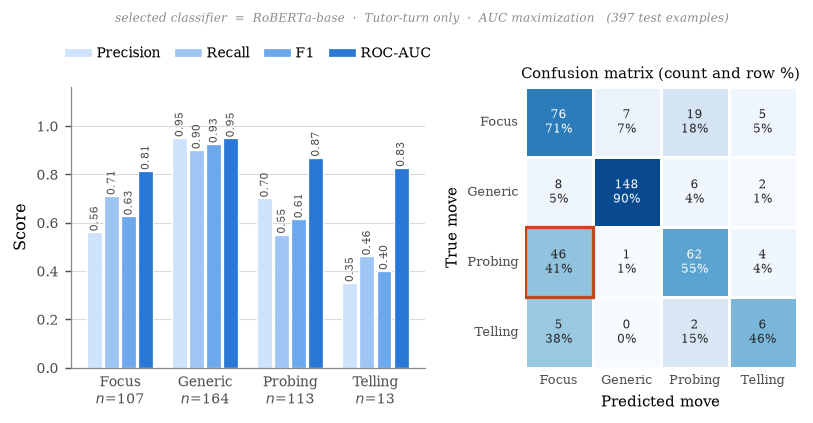

In [211]:
# Per-class rows for the selected classifier only.
selected = pick(per_class, encoder="RoBERTa-base",
                representation="Tutor-turn only", objective="AUC max.")
selected = selected.set_index("move").loc[MOVES]

fig, (left_panel, right_panel) = plt.subplots(
    1, 2, figsize=(7.2, 2.8), gridspec_kw={"width_ratios": [1.3, 1]})

# ---------- left: four bars per move ----------
bar_width = 0.20
x = np.arange(len(MOVES))
columns = [("Precision", "precision"), ("Recall", "recall"),
           ("F1", "f1"), ("ROC-AUC", "auc")]

for i, (label, column) in enumerate(columns):
    position = x + (i - 1.5) * bar_width
    values = selected[column].values
    left_panel.bar(position, values, bar_width * 0.88, color=BLUE_SHADES[i],
                   label=label, edgecolor="white", linewidth=0.7, zorder=2)
    for xi, value in zip(position, values):
        left_panel.annotate(f"{value:.2f}", (xi, value), xytext=(0, 2),
                            textcoords="offset points", ha="center",
                            rotation=90, fontsize=6.3, color=GREY)

left_panel.set_xticks(x)
left_panel.set_xticklabels([f"{MOVE_LABELS[m]}\n$n$={selected.loc[m, 'support']}"
                            for m in MOVES])
left_panel.set_ylim(0, 1.16)
left_panel.set_ylabel("Score")
left_panel.yaxis.grid(True)
left_panel.set_axisbelow(True)
left_panel.tick_params(axis="x", length=0)
left_panel.legend(ncol=4, loc="upper center", bbox_to_anchor=(0.5, 1.19),
                  columnspacing=1.0, handletextpad=0.35, fontsize=7.6)

# ---------- right: confusion matrix ----------
# Cell text: the count, and its share of the row.
row_percent = 100 * confusion.div(confusion.sum(axis=1), axis=0)
cell_labels = confusion.astype(str) + "\n" + row_percent.round(0).astype(int).astype(str) + "%"

sns.heatmap(row_percent, annot=cell_labels, fmt="", cmap="Blues", vmin=0, vmax=100,
            cbar=False, linewidths=1.5, linecolor="white",
            annot_kws={"fontsize": 6.6}, ax=right_panel)

right_panel.set_xticklabels([MOVE_LABELS[m] for m in MOVES], fontsize=7.4, rotation=0)
right_panel.set_yticklabels([MOVE_LABELS[m] for m in MOVES], fontsize=7.4, rotation=0)
right_panel.set_xlabel("Predicted move", fontsize=8.2)
right_panel.set_ylabel("True move", fontsize=8.2)
right_panel.set_title("Confusion matrix (count and row %)", fontsize=8.4, color=INK, pad=5)
right_panel.tick_params(length=0)

# Box on Probing -> Focus. Third row, first column, so the corner sits at (0, 2).
right_panel.add_patch(plt.Rectangle((0, 2), 1, 1, fill=False,
                                    edgecolor="#c2481c", linewidth=1.8))

fig.subplots_adjust(wspace=0.32)
add_model_note(fig, SELECTED_ONLY, y=1.05)

save(fig, "fig_5_6_selected_model")
plt.show()


## 2-7. Figure 5.7 — the rarest move on its own

Top row F1, bottom row ROC-AUC, columns = encoder.

The point: F1 drops all the way to 0.00 in places, ROC-AUC stays between 0.70 and 0.86.
Pale band in the bottom row marks that range.

saved fig_5_7_minority_objective


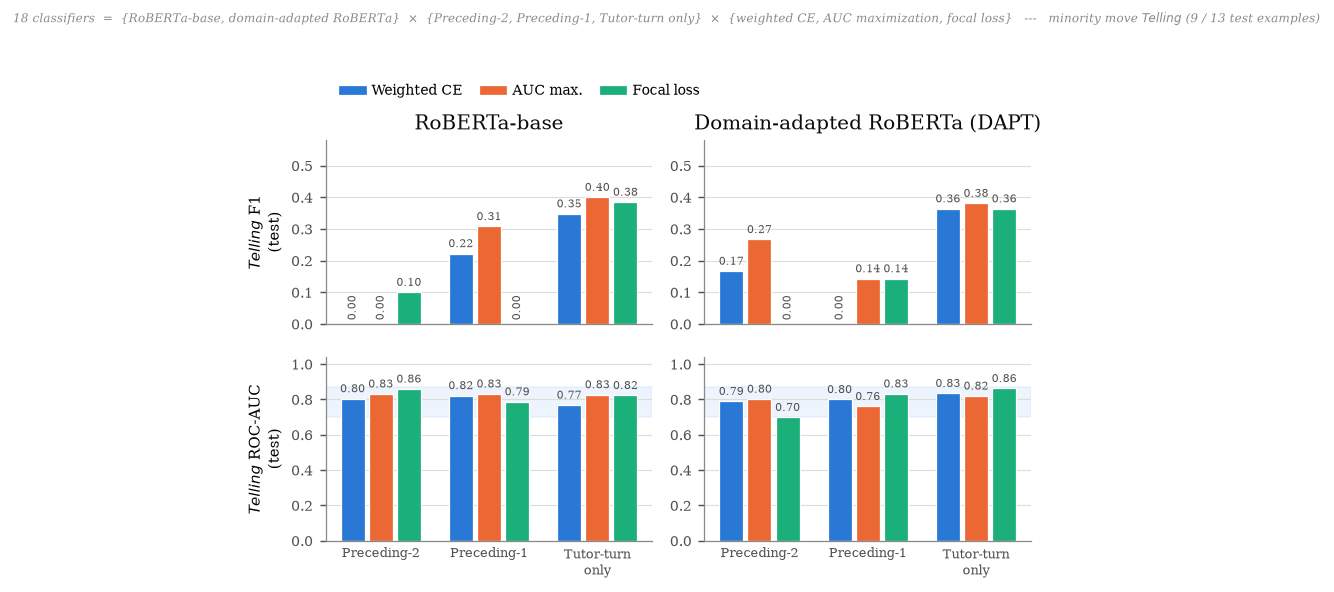

In [212]:
telling = per_class[per_class["move"] == "telling"]

fig, axes = plt.subplots(2, 2, figsize=(7.0, 4.0), sharex=True)

bar_width = 0.26
x = np.arange(len(REPRESENTATIONS))
rows_to_draw = [("f1", "$\\it{Telling}$ F1", 0.58),
                ("auc", "$\\it{Telling}$ ROC-AUC", 1.04)]

for row_index, (column, ylabel, ymax) in enumerate(rows_to_draw):
    for column_index, encoder in enumerate(ENCODERS):
        panel = axes[row_index, column_index]

        for i, objective in enumerate(OBJECTIVES):
            values = []
            for representation in REPRESENTATIONS:
                cell = pick(telling, encoder=encoder,
                            representation=representation, objective=objective)
                values.append(cell[column].item())

            position = x + (i - 1) * bar_width
            panel.bar(position, values, bar_width * 0.85, color=COLOR[objective],
                      label=objective if (row_index == 0 and column_index == 0) else None,
                      edgecolor="white", linewidth=0.7, zorder=2)
            for xi, value in zip(position, values):
                panel.annotate(f"{value:.2f}", (xi, value), xytext=(0, 2),
                               textcoords="offset points", ha="center", va="bottom",
                               rotation=90 if value == 0 else 0,
                               fontsize=6.3, color=GREY)

        if column == "auc":
            panel.axhspan(0.70, 0.87, color="#cde2fb", alpha=0.35, zorder=0)

        panel.set_ylim(0, ymax)
        panel.yaxis.grid(True)
        panel.set_axisbelow(True)
        panel.tick_params(axis="x", length=0)

        if row_index == 0:
            panel.set_title(ENCODER_TITLES[encoder], color=INK, pad=6)
        if column_index == 0:
            panel.set_ylabel(ylabel + "\n(test)", fontsize=8.4)
        if row_index == 1:
            panel.set_xticks(x)
            panel.set_xticklabels([n.replace(" only", "\nonly") for n in REPRESENTATIONS],
                                  fontsize=7.4)

axes[0, 0].legend(ncol=3, loc="lower left", bbox_to_anchor=(0.0, 1.16),
                  columnspacing=1.2, handletextpad=0.35, fontsize=7.8)
fig.subplots_adjust(wspace=0.16, hspace=0.18)
add_model_note(fig, ALL_18 + "   ---   minority move $\\it{Telling}$ (9 / 13 test examples)",
               y=1.10)

save(fig, "fig_5_7_minority_objective")
plt.show()

In [198]:
for file in sorted(FIGURE_DIR.glob("*.pdf")):
    print(f"{file.name:34} {file.stat().st_size / 1024:6.1f} KB")

print()
print("For the thesis, copy the PDFs into:")
print("  __Thesis_writing/TUM_Template/figures/")

5_1_overview.pdf                     36.9 KB
fig_5_1_overview.pdf                 41.5 KB
fig_5_2_perclass.pdf                 40.6 KB
fig_5_3_generic_effect.pdf           40.0 KB
fig_5_4_val_curves.pdf               34.9 KB
fig_5_5_f1_vs_auc.pdf                36.1 KB
fig_5_6_selected_model.pdf           36.1 KB
fig_5_7_minority_objective.pdf       41.8 KB

For the thesis, copy the PDFs into:
  __Thesis_writing/TUM_Template/figures/


In [199]:
# How the "macro-F1 vs macro-AUC don't rank configs the same way" claim was derived.
# Uses the real 18-row `summary` table (not hand-copied numbers), ranks each metric,
# and finds the configuration where the two rankings disagree the most.

from scipy.stats import spearmanr

ranked = summary.copy()
ranked["rank_f1"] = ranked["macro_f1"].rank(ascending=False, method="min").astype(int)
ranked["rank_auc"] = ranked["macro_auc"].rank(ascending=False, method="min").astype(int)
ranked["rank_gap"] = ranked["rank_f1"] - ranked["rank_auc"]

rho, p_value = spearmanr(ranked["macro_f1"], ranked["macro_auc"])
print(f"Spearman rank correlation between macro-F1 and macro-AUC (n={len(ranked)}): "
      f"r_s = {rho:.2f}, p = {p_value:.2g}")

# The configuration whose F1-rank and AUC-rank disagree the most
worst = ranked.loc[ranked["rank_gap"].abs().idxmax()]
print(f"\nLargest rank disagreement: {worst['encoder']}, {worst['representation']}, "
      f"{worst['objective']}")
print(f"  macro-F1  = {worst['macro_f1']:.3f}  -> rank {int(worst['rank_f1'])} of {len(ranked)}")
print(f"  macro-AUC = {worst['macro_auc']:.3f}  -> rank {int(worst['rank_auc'])} of {len(ranked)}")

ranked.sort_values("rank_f1")[
    ["encoder", "representation", "objective", "macro_f1", "rank_f1", "macro_auc", "rank_auc", "rank_gap"]
]

Spearman rank correlation between macro-F1 and macro-AUC (n=18): r_s = 0.79, p = 9.8e-05

Largest rank disagreement: RoBERTa-base, Preceding-2, Weighted CE
  macro-F1  = 0.342  -> rank 17 of 18
  macro-AUC = 0.761  -> rank 7 of 18


,encoder,representation,objective,macro_f1,rank_f1,macro_auc,rank_auc,rank_gap
5,RoBERTa-base,Tutor-turn only,AUC max.,0.6417,1,0.8645,1,0
17,DAPT,Tutor-turn only,Focal loss,0.6249,2,0.8615,2,0
11,DAPT,Tutor-turn only,Weighted CE,0.6231,3,0.7992,6,-3
8,RoBERTa-base,Tutor-turn only,Focal loss,0.6141,4,0.8497,4,0
2,RoBERTa-base,Tutor-turn only,Weighted CE,0.6121,5,0.8340,5,0
14,DAPT,Tutor-turn only,AUC max.,0.6079,6,0.8611,3,3
4,RoBERTa-base,Preceding-1,AUC max.,0.4788,7,0.7555,8,-1
1,RoBERTa-base,Preceding-1,Weighted CE,0.4476,8,0.7513,10,-2
12,DAPT,Preceding-2,AUC max.,0.4069,9,0.7540,9,0
16,DAPT,Preceding-1,Focal loss,0.4057,10,0.7315,14,-4
